In [1]:
import pandas as pd

data = pd.read_csv("aml_syn_data")

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484536 entries, 0 to 1484535
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Time_step           1484536 non-null  object 
 1   Label               1484536 non-null  object 
 2   Transaction_Id      1484536 non-null  object 
 3   Sender_Id           1119436 non-null  object 
 4   Sender_Account      1119436 non-null  object 
 5   Sender_Institution  1119436 non-null  object 
 6   Sender_Country      1119436 non-null  object 
 7   USD_amount          1484536 non-null  float64
 8   Bene_Id             1169913 non-null  object 
 9   Bene_Account        921185 non-null   object 
 10  Bene_Institution    921185 non-null   object 
 11  Bene_Country        921185 non-null   object 
 12  Transaction_Type    1484536 non-null  object 
dtypes: float64(1), object(12)
memory usage: 147.2+ MB


In [3]:
data_bad = data[data["Label"]=="BAD"]
data_bad.head()

,Time_step,Label,Transaction_Id,Sender_Id,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,Bene_Account,Bene_Institution,Bene_Country,Transaction_Type
10038,2022-01-10 00:02:00,BAD,T-778901-00,NaN,NaN,NaN,NaN,290719.0,JPMC-CLIENT-778705-00,CHECKING-778712-00,JPMORGANCHASE,USA,CASH-DEPOSIT
10041,2022-01-10 00:02:00,BAD,T-1611633-00,NaN,NaN,NaN,NaN,0.0,COMPANY-1611618-00,CHECKING-1611448-00,JPMORGANCHASE,USA,KYC-CREATE-ACCOUNT
10045,2022-01-10 00:06:00,BAD,T-2965120-00,NaN,NaN,NaN,NaN,0.0,COMPANY-2965099-00,DIGITAL-MONEY-2964945-00,JPMORGANCHASE,USA,KYC-CREATE-ACCOUNT
10047,2022-01-10 00:06:00,BAD,T-2809205-00,JPMC-CLIENT-2808989-00,CHECKING-2808996-00,JPMORGANCHASE,USA,1000049.0,CUSTOMER-2809006-00,CHECKING-2809007-00,BANK-2809206-00,SYRIA,WIRE
10048,2022-01-10 00:06:00,BAD,T-1855120-00,NaN,NaN,NaN,NaN,61302.0,JPMC-CLIENT-1854927-00,CHECKING-1854935-00,JPMORGANCHASE,USA,CASH-DEPOSIT


In [4]:
print(data.size)
data.isna().sum()

19298968


Time_step                  0
Label                      0
Transaction_Id             0
Sender_Id             365100
Sender_Account        365100
Sender_Institution    365100
Sender_Country        365100
USD_amount                 0
Bene_Id               314623
Bene_Account          563351
Bene_Institution      563351
Bene_Country          563351
Transaction_Type           0
dtype: int64

In [5]:
data.isna().groupby(data['Label']).mean()


,Time_step,Label,Transaction_Id,Sender_Id,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,Bene_Account,Bene_Institution,Bene_Country,Transaction_Type
Label,,,,,,,,,,,,,
BAD,0.0,0.0,0.0,0.392806,0.392806,0.392806,0.392806,0.0,0.208333,0.208333,0.208333,0.208333,0.0
GOOD,0.0,0.0,0.0,0.207021,0.207021,0.207021,0.207021,0.0,0.212888,0.424826,0.424826,0.424826,0.0


In [2]:
# Parse time
data["Time_step"] = pd.to_datetime(data["Time_step"])

# Map accounts to node indices
all_accounts = pd.unique(
    pd.concat([data["Sender_Account"], data["Bene_Account"]], ignore_index=True)
)
acct2idx = {acct: i for i, acct in enumerate(all_accounts)}

data["src"] = data["Sender_Account"].map(acct2idx)
data["dst"] = data["Bene_Account"].map(acct2idx)
data = data.sort_values("Time_step").reset_index(drop=True)
n = len(data)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = data.iloc[:train_end]
val_df   = data.iloc[train_end:val_end]
test_df  = data.iloc[val_end:]

import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Log-scale amount
data["log_amount"] = np.log1p(data["USD_amount"])

# Time features
data["hour"] = data["Time_step"].dt.hour
data["dayofweek"] = data["Time_step"].dt.dayofweek
data["month"] = data["Time_step"].dt.month

# Normalize continuous features (fit on train only)
cont_edge_cols = ["log_amount", "hour", "dayofweek", "month"]
scaler = StandardScaler()
scaler.fit(data.loc[train_df.index, cont_edge_cols])
data[cont_edge_cols] = scaler.transform(data[cont_edge_cols])

# Categorical edge features (transaction type)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(data.loc[train_df.index, ["Transaction_Type"]])
tx_type_ohe = ohe.transform(data[["Transaction_Type"]])

# Assemble edge_attr matrix
import numpy as np

edge_cont = data[cont_edge_cols].to_numpy()
edge_attr = np.hstack([edge_cont, tx_type_ohe])

# Store edge_attr indices per split
edge_attr_train = edge_attr[train_df.index]
edge_attr_val   = edge_attr[val_df.index]
edge_attr_test  = edge_attr[test_df.index]
label_map = {"GOOD": 0, "BAD": 1}
data["y"] = data["Label"].map(label_map)

y_train = data.loc[train_df.index, "y"].to_numpy()
y_val   = data.loc[val_df.index, "y"].to_numpy()
y_test  = data.loc[test_df.index, "y"].to_numpy()

# Build basic per-account stats using all data
sent_stats = train_df.groupby("src").agg(
    sent_count=("src", "size"),
    sent_total_amount=("USD_amount", "sum"),
    sent_avg_amount=("USD_amount", "mean"),
)

recv_stats = train_df.groupby("dst").agg(
    recv_count=("dst", "size"),
    recv_total_amount=("USD_amount", "sum"),
    recv_avg_amount=("USD_amount", "mean"),
)

num_nodes = len(all_accounts)
node_stats = (
    sent_stats.join(recv_stats, how="outer")
    .reindex(range(num_nodes))
    .fillna(0.0)
)

assert node_stats.shape[0] <= num_nodes

from sklearn.preprocessing import StandardScaler
import numpy as np

def most_frequent_or_nan(x):
    vc = x.value_counts(dropna=True)
    if vc.empty:
        return np.nan
    return vc.index[0]

# Dominant sender country per account (by src)
dom_country = (
    data.groupby("src")["Sender_Country"]
        .agg(most_frequent_or_nan)
        .reindex(range(num_nodes))  # ensure index 0..num_nodes-1
)

# Optionally fill unknowns
dom_country = dom_country.fillna("UNKNOWN")

from sklearn.preprocessing import OneHotEncoder
import torch
from torch_geometric.data import Data

ohe_country = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
country_ohe = ohe_country.fit_transform(dom_country.to_frame())

# --- Scale numeric node stats and concatenate with country one-hot ---
node_scaler = StandardScaler()
node_num = node_scaler.fit_transform(node_stats.values.astype("float32"))

node_features = np.hstack([node_num, country_ohe])
x = torch.from_numpy(node_features).float()

edge_index = torch.as_tensor(
    np.vstack([data["src"].to_numpy(), data["dst"].to_numpy()]),
    dtype=torch.long
)

edge_attr_t = torch.tensor(edge_attr, dtype=torch.float)
y = torch.tensor(data["y"].to_numpy(), dtype=torch.float)

data2 = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr_t
)


# Edge masks for splits
train_mask = torch.zeros(edge_index.size(1), dtype=torch.bool)
val_mask   = torch.zeros(edge_index.size(1), dtype=torch.bool)
test_mask  = torch.zeros(edge_index.size(1), dtype=torch.bool)

train_mask[train_df.index] = True
val_mask[val_df.index] = True
test_mask[test_df.index] = True

data2.train_mask = train_mask
data2.val_mask   = val_mask
data2.test_mask  = test_mask
data2.y          = y  # edge-level labels


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class EdgeClassifierGNN(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(node_in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # binary logit
        )

    def forward(self, x, edge_index, edge_attr):
        # Node embedding
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        src, dst = edge_index
        h_src = x[src]
        h_dst = x[dst]

        edge_repr = torch.cat([h_src, h_dst, edge_attr], dim=-1)
        logit = self.edge_mlp(edge_repr).squeeze(-1)  # [num_edges]

        return logit


First Model Results

Epoch 1 | train_loss=5.8186 | val_f1=0.4608
Epoch 2 | train_loss=5.4952 | val_f1=0.4608
Epoch 3 | train_loss=5.1734 | val_f1=0.4608
Epoch 4 | train_loss=4.8549 | val_f1=0.4608
Epoch 5 | train_loss=4.5398 | val_f1=0.4608
Epoch 6 | train_loss=4.2293 | val_f1=0.4608
Epoch 7 | train_loss=3.9225 | val_f1=0.4608
Epoch 8 | train_loss=3.6212 | val_f1=0.4608
Epoch 9 | train_loss=3.3261 | val_f1=0.4608
Epoch 10 | train_loss=3.0386 | val_f1=0.4607
Epoch 11 | train_loss=2.7628 | val_f1=0.4608
Epoch 12 | train_loss=2.5059 | val_f1=0.4607
Epoch 13 | train_loss=2.2783 | val_f1=0.4606
Epoch 14 | train_loss=2.0888 | val_f1=0.4581
Epoch 15 | train_loss=1.9419 | val_f1=0.3364
Epoch 16 | train_loss=1.8281 | val_f1=0.3502
Epoch 17 | train_loss=1.7355 | val_f1=0.3498
Epoch 18 | train_loss=1.6546 | val_f1=0.3399
Epoch 19 | train_loss=1.5801 | val_f1=0.2716
Epoch 20 | train_loss=1.5127 | val_f1=0.2700
Epoch 21 | train_loss=1.4549 | val_f1=0.2667
Epoch 22 | train_loss=1.4032 | val_f1=0.2620
Epoch 23 | train_loss=1.3558 | val_f1=0.3018
Epoch 24 | train_loss=1.3108 | val_f1=0.3326
Epoch 25 | train_loss=1.2652 | val_f1=0.3228
...
Epoch 47 | train_loss=0.9896 | val_f1=0.6187
Epoch 48 | train_loss=0.9772 | val_f1=0.6179
Epoch 49 | train_loss=0.9668 | val_f1=0.6185
Epoch 50 | train_loss=0.9585 | val_f1=0.6220

In [12]:
import copy

best_f1 = -1
best_epoch = -1
best_state = None


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EdgeClassifierGNN(
    node_in_dim=data2.x.size(1),
    edge_in_dim=data2.edge_attr.size(1),
    hidden_dim=64
).to(device)

data2 = data2.to(device)
y_train_t = data2.y[data2.train_mask]
num_pos = (y_train_t == 1).sum()
num_neg = (y_train_t == 0).sum()
pos_weight = num_neg / num_pos

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

train_losses = []
val_f1s = []

for epoch in range(1, 51):
    model.train()
    optimizer.zero_grad()

    logits = model(data2.x, data2.edge_index, data2.edge_attr)
    loss = criterion(logits[data2.train_mask], data2.y[data2.train_mask])

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = logits[data2.val_mask]
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_labels = data2.y[data2.val_mask]

        # simple metrics
        from sklearn.metrics import f1_score
        f1 = f1_score(val_labels.cpu(), val_preds.cpu())

    val_f1s.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())


    print(f"Epoch {epoch} | train_loss={loss.item():.4f} | val_f1={f1:.4f}")

Epoch 1 | train_loss=4.6280 | val_f1=0.0103
Epoch 2 | train_loss=3.9347 | val_f1=0.0122
Epoch 3 | train_loss=3.2603 | val_f1=0.0131
Epoch 4 | train_loss=2.6306 | val_f1=0.1748
Epoch 5 | train_loss=2.0990 | val_f1=0.2432
Epoch 6 | train_loss=1.7319 | val_f1=0.2230
Epoch 7 | train_loss=1.5460 | val_f1=0.2926
Epoch 8 | train_loss=1.4970 | val_f1=0.3357
Epoch 9 | train_loss=1.5242 | val_f1=0.4185
Epoch 10 | train_loss=1.5665 | val_f1=0.4426
Epoch 11 | train_loss=1.5889 | val_f1=0.4515
Epoch 12 | train_loss=1.5738 | val_f1=0.4528
Epoch 13 | train_loss=1.5261 | val_f1=0.4487
Epoch 14 | train_loss=1.4608 | val_f1=0.4369
Epoch 15 | train_loss=1.3972 | val_f1=0.4105
Epoch 16 | train_loss=1.3524 | val_f1=0.6017
Epoch 17 | train_loss=1.3311 | val_f1=0.5991
Epoch 18 | train_loss=1.3258 | val_f1=0.5862
Epoch 19 | train_loss=1.3248 | val_f1=0.5762
Epoch 20 | train_loss=1.3201 | val_f1=0.5728
Epoch 21 | train_loss=1.3075 | val_f1=0.5711
Epoch 22 | train_loss=1.2871 | val_f1=0.5703
Epoch 23 | train_lo

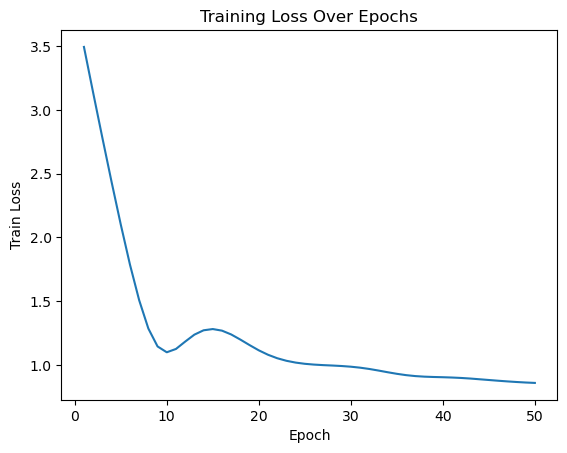

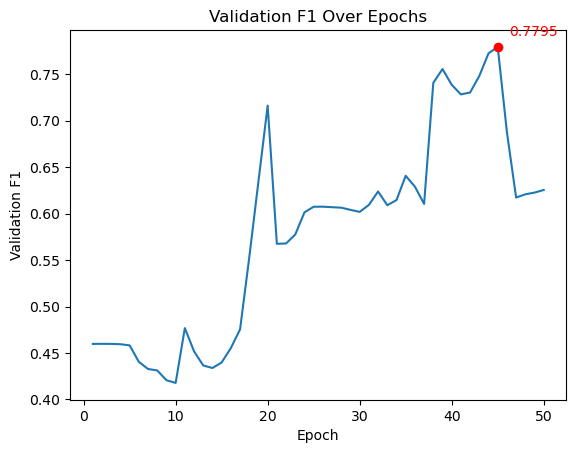

In [7]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Epochs")
plt.show()

best_f1 = max(val_f1s)
best_idx = val_f1s.index(best_f1)
best_epoch = epochs[best_idx]

plt.figure()
plt.plot(epochs, val_f1s)
plt.scatter([best_epoch], [best_f1], color="red", zorder=5, label=f"Best F1 = {best_f1:.4f}")
plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Validation F1 Over Epochs")

plt.annotate(
    f"{best_f1:.4f}",
    (best_epoch, best_f1),
    textcoords="offset points",
    xytext=(8, 8),
    ha="left",
    color="red"
)
plt.show()


In [13]:
# Load best weights
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    test_logits = model(data2.x, data2.edge_index, data2.edge_attr)[data2.test_mask]
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs > 0.5).float()
    test_labels = data2.y[data2.test_mask]

    from sklearn.metrics import f1_score, classification_report
    test_f1 = f1_score(test_labels.view(-1).cpu(), test_preds.view(-1).cpu())

print(f"Test F1 (best epoch) = {test_f1:.4f}")


Test F1 (best epoch) = 0.2879


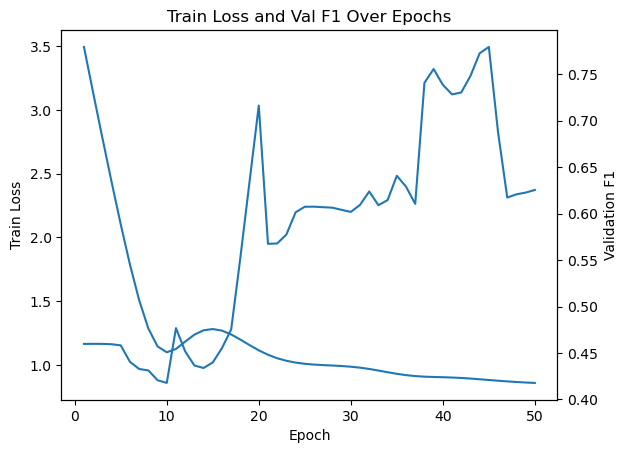

In [5]:
fig, ax1 = plt.subplots()

ax1.plot(epochs, train_losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")

ax2 = ax1.twinx()
ax2.plot(epochs, val_f1s)
ax2.set_ylabel("Validation F1")

plt.title("Train Loss and Val F1 Over Epochs")
plt.show()


In [14]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    logits = model(data2.x, data2.edge_index, data2.edge_attr)
    test_logits = logits[data2.test_mask]
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs > 0.5).float()
    test_labels = data2.y[data2.test_mask]

test_f1 = f1_score(test_labels.cpu(), test_preds.cpu())
cm = confusion_matrix(test_labels.cpu(), test_preds.cpu())
report = classification_report(test_labels.cpu(), test_preds.cpu(), digits=4)

print("Test F1:", test_f1)
print("Test confusion matrix:\n", cm)
print("Test class distribution:\n", np.bincount(test_labels.cpu().numpy().astype(int)))
print("Test classification report2:\n", report)


Test F1: 0.2878985107556536
Test confusion matrix:
 [[145080  59645]
 [  4907  13049]]
Test class distribution:
 [204725  17956]
Test classification report2:
               precision    recall  f1-score   support

         0.0     0.9673    0.7087    0.8180    204725
         1.0     0.1795    0.7267    0.2879     17956

    accuracy                         0.7101    222681
   macro avg     0.5734    0.7177    0.5530    222681
weighted avg     0.9038    0.7101    0.7753    222681



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Simple logistic regression baseline on edge_attr
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handle class imbalance
    n_jobs=-1
)
log_reg.fit(edge_attr_train, y_train)

val_pred_lr = log_reg.predict(edge_attr_val)
test_pred_lr = log_reg.predict(edge_attr_test)

val_f1_lr = f1_score(y_val, val_pred_lr)
test_f1_lr = f1_score(y_test, test_pred_lr)

print(f"LogReg baseline | val_f1={val_f1_lr:.4f} | test_f1={test_f1_lr:.4f}")



LogReg baseline | val_f1=0.9975 | test_f1=0.9964


In [15]:
print("overlap train/test:", set(train_df.index) & set(test_df.index))
print("overlap train/val:",  set(train_df.index) & set(val_df.index))
print("overlap val/test:",   set(val_df.index) & set(test_df.index))


overlap train/test: set()
overlap train/val: set()
overlap val/test: set()


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, test_pred_lr)
print("Confusion matrix:\n", cm)
print("Classification report:\n", classification_report(y_test, test_pred_lr, digits=4))

Confusion matrix:
 [[204725      0]
 [   130  17826]]
Classification report:
               precision    recall  f1-score   support

           0     0.9994    1.0000    0.9997    204725
           1     1.0000    0.9928    0.9964     17956

    accuracy                         0.9994    222681
   macro avg     0.9997    0.9964    0.9980    222681
weighted avg     0.9994    0.9994    0.9994    222681



In [17]:
# Always predict GOOD (0)
all_good = np.zeros_like(y_test)
print("All-good baseline F1:", f1_score(y_test, all_good))

# Random predictions
rng = np.random.default_rng(42)
random_preds = rng.integers(0, 2, size=y_test.shape[0])
print("Random baseline F1:", f1_score(y_test, random_preds))


All-good baseline F1: 0.0
Random baseline F1: 0.13908598871190656


In [18]:
print(edge_attr.shape)
print(cont_edge_cols)  # should be just the numeric ones you expect
print(ohe.get_feature_names_out(["Transaction_Type"]))

(1484536, 11)
['log_amount', 'hour', 'dayofweek', 'month']
['Transaction_Type_CASH-DEPOSIT' 'Transaction_Type_CRYPTO-TRANSFER'
 'Transaction_Type_KYC-ADD-ACCOUNT-OWNER'
 'Transaction_Type_KYC-CREATE-ACCOUNT' 'Transaction_Type_PAYMENT'
 'Transaction_Type_WIRE' 'Transaction_Type_WITHDRAWL']


In [19]:
# Permute labels in TRAIN only
y_train_perm = np.random.permutation(y_train)

log_reg_perm = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)
log_reg_perm.fit(edge_attr_train, y_train_perm)

test_pred_perm = log_reg_perm.predict(edge_attr_test)
print("F1 with permuted train labels:",
      f1_score(y_test, test_pred_perm))


F1 with permuted train labels: 0.11208016826762054


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# ----- Decision Tree baseline on edge_attr -----
dt = DecisionTreeClassifier(
    max_depth=10,          # cap depth to avoid overfitting
    min_samples_leaf=50,   # require some support per leaf
    class_weight="balanced",  # handle class imbalance
    random_state=42
)

dt.fit(edge_attr_train, y_train)

# Validation performance
val_pred_dt = dt.predict(edge_attr_val)
val_f1_dt = f1_score(y_val, val_pred_dt)
val_cm_dt = confusion_matrix(y_val, val_pred_dt)
print(f"DecisionTree | val_f1={val_f1_dt:.4f}")
print("DecisionTree | val_confusion_matrix:\n", val_cm_dt)

# Test performance
test_pred_dt = dt.predict(edge_attr_test)
test_f1_dt = f1_score(y_test, test_pred_dt)
test_cm_dt = confusion_matrix(y_test, test_pred_dt)
print(f"DecisionTree | test_f1={test_f1_dt:.4f}")
print("DecisionTree | test_confusion_matrix:\n", test_cm_dt)

# Optional: detailed report on test set
print("DecisionTree | test_classification_report:\n",
      classification_report(y_test, test_pred_dt, digits=4))


DecisionTree | val_f1=0.9985
DecisionTree | val_confusion_matrix:
 [[156008      8]
 [   191  66473]]
DecisionTree | test_f1=0.9986
DecisionTree | test_confusion_matrix:
 [[204719      6]
 [    46  17910]]
DecisionTree | test_classification_report:
               precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999    204725
           1     0.9997    0.9974    0.9986     17956

    accuracy                         0.9998    222681
   macro avg     0.9997    0.9987    0.9992    222681
weighted avg     0.9998    0.9998    0.9998    222681



In [13]:
#Using Graph Attention Network


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv  # NEW import

class EdgeClassifierGAT(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim=64, heads=4):
        super().__init__()
        # First GAT layer: multi-head, concatenated
        self.conv1 = GATConv(
            in_channels=node_in_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=True,     # output dim = hidden_dim * heads
            dropout=0.2
        )
        # Second GAT layer: single head, no concat
        self.conv2 = GATConv(
            in_channels=hidden_dim * heads,
            out_channels=hidden_dim,
            heads=1,
            concat=False,    # output dim = hidden_dim
            dropout=0.2
        )

        # Edge-level classifier on [h_src, h_dst, edge_attr]
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # binary logit
        )

    def forward(self, x, edge_index, edge_attr):
        # Node embeddings with attention-based message passing
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))

        src, dst = edge_index
        h_src = x[src]
        h_dst = x[dst]

        edge_repr = torch.cat([h_src, h_dst, edge_attr], dim=-1)
        logit = self.edge_mlp(edge_repr).squeeze(-1)  # [num_edges]

        return logit


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EdgeClassifierGAT(
    node_in_dim=data2.x.size(1),
    edge_in_dim=data2.edge_attr.size(1),
    hidden_dim=64,
    heads=4
).to(device)

data2 = data2.to(device)

y_train_t = data2.y[data2.train_mask]
num_pos = (y_train_t == 1).sum().item()
num_neg = (y_train_t == 0).sum().item()
pos_weight = num_neg / num_pos
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, device=device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

for epoch in range(1, 51):
    model.train()
    optimizer.zero_grad()

    logits = model(data2.x, data2.edge_index, data2.edge_attr)
    loss = criterion(logits[data2.train_mask], data2.y[data2.train_mask])

    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = logits[data2.val_mask]
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_labels = data2.y[data2.val_mask]

        from sklearn.metrics import f1_score
        f1 = f1_score(val_labels.cpu(), val_preds.cpu())

    print(f"Epoch {epoch} | train_loss={loss.item():.4f} | val_f1={f1:.4f}")


Epoch 1 | train_loss=2.8398 | val_f1=0.0632
Epoch 2 | train_loss=2.1066 | val_f1=0.0771
Epoch 3 | train_loss=1.5944 | val_f1=0.1319
Epoch 4 | train_loss=1.3940 | val_f1=0.2660
Epoch 5 | train_loss=1.5444 | val_f1=0.4258
Epoch 6 | train_loss=1.6878 | val_f1=0.4287
Epoch 7 | train_loss=1.7139 | val_f1=0.4293
Epoch 8 | train_loss=1.6352 | val_f1=0.4293
Epoch 9 | train_loss=1.5336 | val_f1=0.4306
Epoch 10 | train_loss=1.2929 | val_f1=0.4372
Epoch 11 | train_loss=1.2131 | val_f1=0.4215
Epoch 12 | train_loss=1.1735 | val_f1=0.5249
Epoch 13 | train_loss=1.1699 | val_f1=0.4836
Epoch 14 | train_loss=1.2485 | val_f1=0.4447
Epoch 15 | train_loss=1.2717 | val_f1=0.4456
Epoch 16 | train_loss=1.2572 | val_f1=0.4528
Epoch 17 | train_loss=1.2414 | val_f1=0.4688
Epoch 18 | train_loss=1.1988 | val_f1=0.4708
Epoch 19 | train_loss=1.1590 | val_f1=0.4812
Epoch 20 | train_loss=1.1326 | val_f1=0.4885
Epoch 21 | train_loss=1.1118 | val_f1=0.5432
Epoch 22 | train_loss=1.1133 | val_f1=0.5638
Epoch 23 | train_lo

In [20]:
# How often is each Transaction_Type BAD?
print(pd.crosstab(data["Transaction_Type"], data["Label"], normalize="index"))


Label                       BAD      GOOD
Transaction_Type                         
CASH-DEPOSIT           0.347478  0.652522
CRYPTO-TRANSFER        1.000000  0.000000
KYC-ADD-ACCOUNT-OWNER  0.354739  0.645261
KYC-CREATE-ACCOUNT     0.231048  0.768952
PAYMENT                0.155408  0.844592
WIRE                   0.032106  0.967894
WITHDRAWL              0.205900  0.794100


In [22]:
# Example: Transaction_Type x Sender_Country (or some other cat)
print(pd.crosstab(
    [data["Transaction_Type"], data["Sender_Country"]],
    data["Label"],
    normalize="index"
))


Label                               BAD  GOOD
Transaction_Type Sender_Country              
CRYPTO-TRANSFER  ARGENTINA          1.0   0.0
                 AUSTRALIA          1.0   0.0
                 CANADA             1.0   0.0
                 CHILE              1.0   0.0
                 CHINA              1.0   0.0
                 FRANCE             1.0   0.0
                 GERMANY            1.0   0.0
                 INDIA              1.0   0.0
                 ISLE-OF-MAN        1.0   0.0
                 ISRAEL             1.0   0.0
                 ITALY              1.0   0.0
                 LUXEMBOURG         1.0   0.0
                 MAROCCO            1.0   0.0
                 MEXICO             1.0   0.0
                 NICARAGUA          1.0   0.0
                 NIGERIA            1.0   0.0
                 PANAMA             1.0   0.0
                 PORTUGAL           1.0   0.0
                 QATAR              1.0   0.0
                 RUSSIA           

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def run_lr(X_train, X_val, X_test, y_train, y_val, y_test, desc):
    lr = LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=-1
    )
    lr.fit(X_train, y_train)
    val_f1 = f1_score(y_val, lr.predict(X_val))
    test_f1 = f1_score(y_test, lr.predict(X_test))
    print(f"{desc} | val_f1={val_f1:.4f} | test_f1={test_f1:.4f}")

# continuous part and tx-type part
edge_cont = data[["log_amount", "hour", "dayofweek", "month"]].to_numpy()

X_train_cont = edge_cont[train_df.index]
X_val_cont   = edge_cont[val_df.index]
X_test_cont  = edge_cont[test_df.index]

X_train_tx = tx_type_ohe[train_df.index]
X_val_tx   = tx_type_ohe[val_df.index]
X_test_tx  = tx_type_ohe[test_df.index]

run_lr(X_train_cont, X_val_cont, X_test_cont, y_train, y_val, y_test, "LR: continuous only")
run_lr(X_train_tx,   X_val_tx,   X_test_tx,   y_train, y_val, y_test, "LR: tx-type only")
run_lr(edge_attr_train, edge_attr_val, edge_attr_test,
       y_train, y_val, y_test, "LR: all edge features")


LR: continuous only | val_f1=0.9976 | test_f1=0.9980
LR: tx-type only | val_f1=0.5289 | test_f1=0.1970
LR: all edge features | val_f1=0.9975 | test_f1=0.9964


In [24]:
import numpy as np
import pandas as pd

# Choose how many bins you want
num_bins = 10

# Build equal-width bins over the range of log_amount
bins = np.linspace(data["log_amount"].min(),
                   data["log_amount"].max(),
                   num_bins + 1)

data["log_amount_bin"] = pd.cut(
    data["log_amount"],
    bins=bins,
    include_lowest=True
)

# Fraction BAD/GOOD in each log_amount bin
print(pd.crosstab(
    data["log_amount_bin"],
    data["Label"],
    normalize="index"
))


Label                               BAD      GOOD
log_amount_bin                                   
(-2.1839999999999997, -1.713]  0.297492  0.702508
(-1.713, -1.244]               0.000122  0.999878
(-1.244, -0.774]               0.000029  0.999971
(-0.774, -0.304]               0.000081  0.999919
(-0.304, 0.165]                0.000726  0.999274
(0.165, 0.635]                 0.005277  0.994723
(0.635, 1.104]                 0.959616  0.040384
(1.104, 1.574]                 1.000000  0.000000
(1.574, 2.044]                 1.000000  0.000000
(2.044, 2.513]                 1.000000  0.000000


In [25]:
from sklearn.tree import DecisionTreeClassifier

X = data[["log_amount"]].to_numpy()
y = data["y"].to_numpy()  # 0 = GOOD, 1 = BAD

# Depth-1 tree = single threshold on log_amount
stump = DecisionTreeClassifier(
    max_depth=1,
    class_weight="balanced",
    random_state=42
)
stump.fit(X, y)

threshold = stump.tree_.threshold[0]
print("Best 1D threshold on log_amount:", threshold)

low_mask  = data["log_amount"] <= threshold
high_mask = data["log_amount"] > threshold

print("Below or equal to threshold:")
print(pd.crosstab(low_mask, data["Label"], normalize="index"))

# Or more explicitly:
print("<= threshold:")
print(pd.crosstab(
    pd.Series(np.where(low_mask, "<= threshold", "> threshold")),
    data["Label"],
    normalize="index"
))


Best 1D threshold on log_amount: 0.39579328894615173
Below or equal to threshold:
Label            BAD      GOOD
log_amount                    
False       0.990354  0.009646
True        0.024110  0.975890
<= threshold:
Label              BAD      GOOD
row_0                           
<= threshold  0.024110  0.975890
> threshold   0.990354  0.009646


In [5]:
unique_values = data[data["Label"]=="BAD"]['Bene_Country'].unique()
print(unique_values)

['USA' 'SYRIA' 'PORTUGAL' 'VENEZUELA' 'UNITED-KINGDOM' 'NORTH-KOREA'
 'ISLE-OF-MAN' nan 'SINGAPORE' 'RUSSIA' 'IRAN' 'GERMANY' 'LUXEMBOURG'
 'FRANCE' 'PANAMA' 'MAROCCO' 'SWEDEN' 'NIGERIA' 'ISRAEL' 'AUSTRALIA'
 'SWITZERLAND' 'ITALY' 'NICARAGUA' 'CHILE' 'MEXICO' 'INDIA' 'CANADA'
 'CHINA' 'SOUTH-KOREA' 'VIRGIN-ISLANDS-US' 'SOUTH-AFRICA' 'ARGENTINA'
 'QATAR' 'SPAIN']
